# Algorytmy genetyczne

## Zadania do samodzielnego wykonania

1.

Proszę zaproponować swoją implementację algorytmu genetycznego w celu znalezienia maksimum funkcji  
$$
f(x) = \cos(80x + 0.3) + 3(x+1)^{-0.9} + 3x^2-\sqrt{x}
$$  
w przedziale $[0, 1]$. Proszę porównać działanie algorytmu:

* Dla kodowania w naturalnym kodzie binarnym i w kodzie Graya
* Dla szansy mutacji wynoszącej 0, 0.1, 0.5 i 1.0
* Dla selekcji ruletkowej i dla selekcji progowej. W selekcji progowej dzielimy populację na dwie grupy: na $\gamma\%$ najlepszych i na pozostałych. Osobniki w grupie $\gamma\%$ najlepszych mają równą szansę na reprodukcję, pozostałe mają zerową szansę na reprodukcję. Proszę sprawdzić wyniki dla $\gamma = 30$ i $\gamma = 60$.

Za każdym razem proszę podać średnie wyniki dla 10 wywołań algorytmu i przedstawić przykładowe przebiegi algorytmu na wykresach (dla jednego z wywołań).

2.

W mieście, reprezentowanym za pomocą kwadratowej siatki, operujemy siecią pizzerii. Ich lokalizacje znajdują się w kwadratach o pozycjach (1,1), (2,6), (5,4), (7,1), albo jak pokazano na obrazku poniżej.

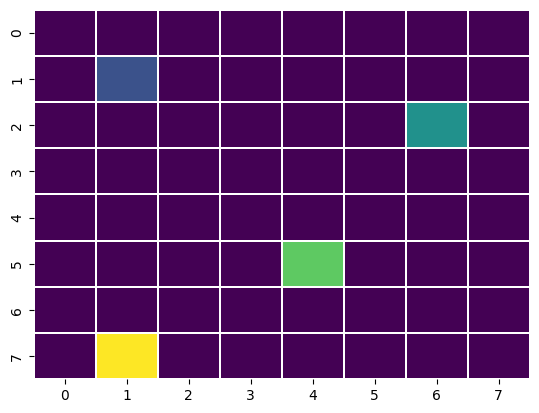

Zyski sieci zależą od budżetu wyłożonego na cztery pizzerie ($B_1$, $B_2$, $B_3$, $B_4$), gdzie każdy budżet jest w zakresie od **0 do 400** (nie może wyjść poza te wartości). Zysk jest liczony w następujący sposób:

$$
Z = \sum_{i=0}^8 \sum_{j=0}^8 \frac{z_{i,j}^1 + z_{i,j}^2 + z_{i,j}^3 + z_{i,j}^4}{4} - (B_1+B_2+B_3+B_4)^{1.15}
$$

Gdzie $z_{i,j}^k$ jest dochodem $k$-tej pizzerii na polu $(i,j)$. Innymi słowy, sumujemy **średnie zyski** z danego pola dla wszystkich pizzerii i odejmujemy od tego skorygowaną (potęgowaną) sumę budżetów — ze względu na konieczność rozbudowy lokali, większe trudności w utrzymaniu itp.

Zysk $k$-tej pizzerii na polu $(i,j)$ liczymy natomiast następująco:

Najpierw liczymy $d$, czyli odległość taksówkarską (taxicab, Manhattan Distance) między pizzerią a tym polem.

- Jeżeli $d$ jest **mniejsza** niż 2:

$$
z = 1.3 \cdot \frac{B}{0.5d + 4}
$$

- Jeżeli $d$ jest **większa lub równa** 2:

$$
z = \frac{B}{0.5d + 4}
$$

---

Proszę zaprojektować **algorytm genetyczny**, który otrzyma jak najwyższą wartość funkcji $Z(B_1, B_2, B_3, B_4)$ i przedstawić, jak radzi sobie przy 10 wywołaniach (jak wygląda średnia wyniku i odchylenie standardowe).

Proszę samodzielnie wybrać **kodowanie** (rzeczywistoliczbowe, całkowitoliczbowe, binarne), wybrać **algorytm mutacji i selekcji**, oraz przeprowadzić **testy parametrów**.


# Zadanie 1

Uruchamianie: Bin_pm0.0_roulette
Uruchamianie: Bin_pm0.1_roulette
Uruchamianie: Bin_pm0.5_roulette
Uruchamianie: Bin_pm1.0_roulette
Uruchamianie: Gray_pm0.0_roulette
Uruchamianie: Gray_pm0.1_roulette
Uruchamianie: Gray_pm0.5_roulette
Uruchamianie: Gray_pm1.0_roulette
Uruchamianie: Bin_pm0.1_threshold_T2
Uruchamianie: Bin_pm0.1_threshold_T5
Uruchamianie: Gray_pm0.1_threshold_T2
Uruchamianie: Gray_pm0.1_threshold_T5

=== Średnie wyniki po 10 uruchomieniach (100 generacji) ===

Bin_pm0.0_roulette        : 4.2939 ± 0.0950
Bin_pm0.1_roulette        : 4.3295 ± 0.0000
Bin_pm0.5_roulette        : 4.3294 ± 0.0001
Bin_pm1.0_roulette        : 4.3295 ± 0.0000
Gray_pm0.0_roulette       : 4.2966 ± 0.0979
Gray_pm0.1_roulette       : 4.3295 ± 0.0000
Gray_pm0.5_roulette       : 4.3295 ± 0.0000
Gray_pm1.0_roulette       : 4.3281 ± 0.0043
Bin_pm0.1_threshold_T2    : 4.2850 ± 0.1100
Bin_pm0.1_threshold_T5    : 4.3295 ± 0.0000
Gray_pm0.1_threshold_T2   : 4.3295 ± 0.0000
Gray_pm0.1_threshold_T5   : 4.3295 ±

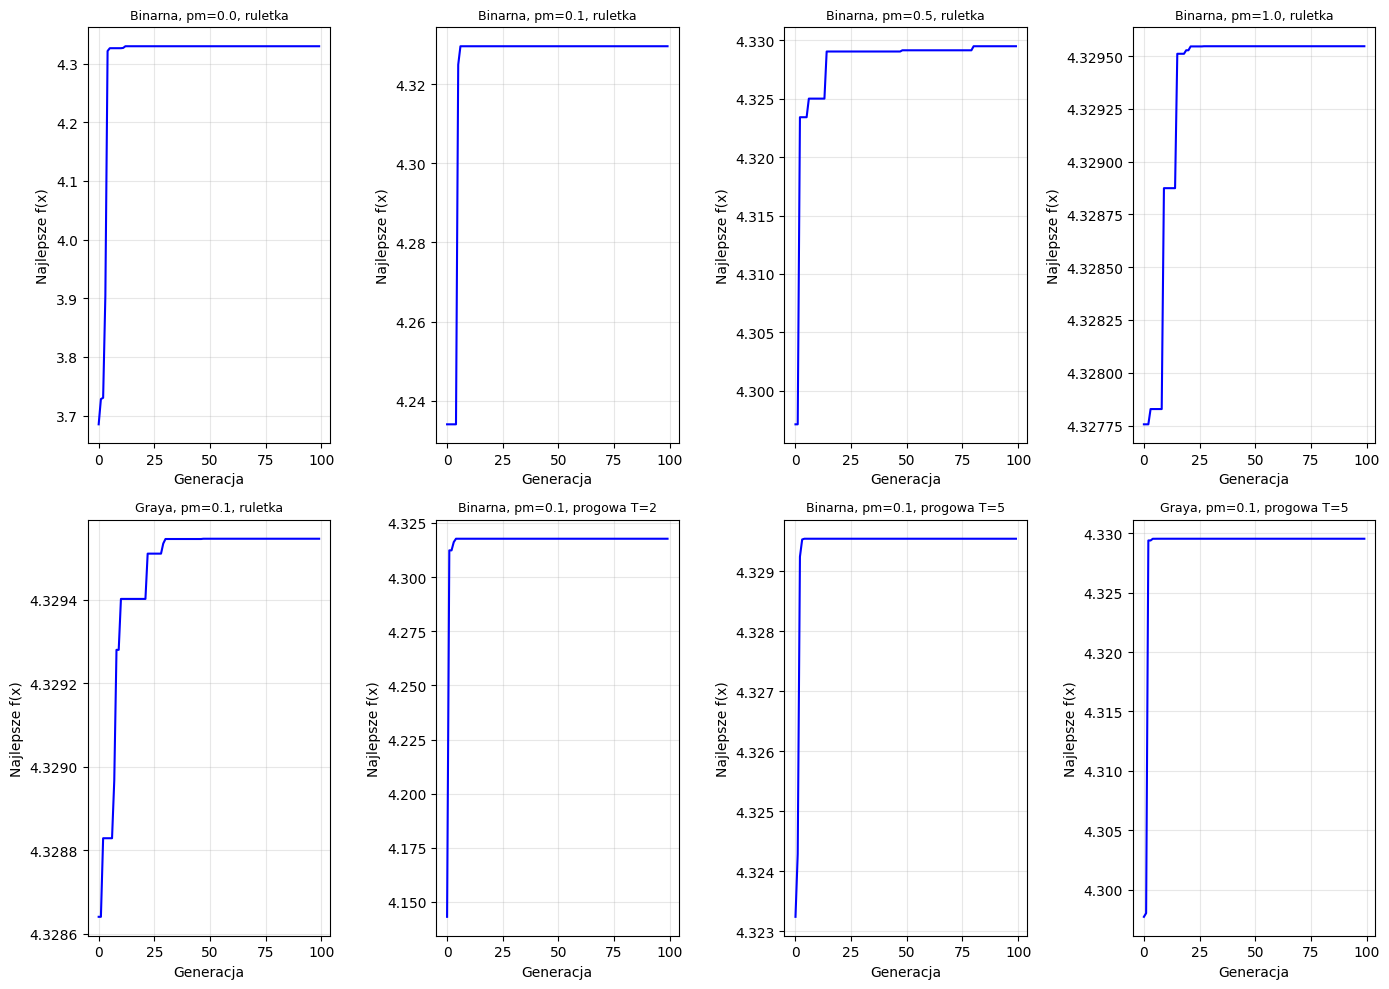

In [8]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# ----------------------------------------------------------------------
# Funkcja celu (do maksymalizacji)
# f(x) = cos(80x + 0.3) + 3(x+1)^{-0.9} + 3x^2-sqrt{x}
def f(x):
    return math.cos(80*x + 0.3) + 3*(x+1)**(-0.9) + 3*x**2 - math.sqrt(x)

# ----------------------------------------------------------------------
# Konwersja binarna <-> Gray
def gray_encode(bits):
    """bits: lista intów 0/1, zwraca kod Graya (lista)"""
    gray = [bits[0]]
    for i in range(1, len(bits)):
        gray.append(bits[i-1] ^ bits[i])
    return gray

def gray_decode(gray):
    """z kodu Graya do binarnego (lista)"""
    bits = [gray[0]]
    for i in range(1, len(gray)):
        bits.append(bits[-1] ^ gray[i])
    return bits

# ----------------------------------------------------------------------
# Klasa osobnika
class Individual:
    L = 16  # długość chromosomu
    def __init__(self, genes=None, use_gray=False):
        if genes is None:
            self.genes = [random.randint(0,1) for _ in range(self.L)]
        else:
            self.genes = genes[:]
        self.use_gray = use_gray
        self.fitness = None

    def decode(self):
        if self.use_gray:
            bin_genes = gray_decode(self.genes)
        else:
            bin_genes = self.genes
        # wartość całkowita [0, 2^L-1]
        val = int(''.join(str(b) for b in bin_genes), 2)
        x = val / (2**self.L)
        return x

    def evaluate(self):
        x = self.decode()
        self.fitness = f(x)
        return self.fitness

    def clone(self):
        return Individual(self.genes, self.use_gray)

# ----------------------------------------------------------------------
# Operatory genetyczne
def crossover(parent1, parent2):
    """jednopunktowe krzyżowanie"""
    pos = random.randint(1, Individual.L-1)
    child1_genes = parent1.genes[:pos] + parent2.genes[pos:]
    child2_genes = parent2.genes[:pos] + parent1.genes[pos:]
    return Individual(child1_genes, parent1.use_gray), Individual(child2_genes, parent1.use_gray)

def mutate(individual, pm):
    """mutacja bitowa z prawdopodobieństwem pm na bit"""
    for i in range(Individual.L):
        if random.random() < pm:
            individual.genes[i] ^= 1

# ----------------------------------------------------------------------
# Selekcje
def roulette_selection(population, fitnesses):
    """selekcja ruletkowa (fitness nieujemny)"""
    # przesunięcie, aby wartości były nieujemne
    min_fit = min(fitnesses)
    if min_fit < 0:
        shifted = [fit - min_fit + 1e-6 for fit in fitnesses]
    else:
        shifted = fitnesses[:]
    total = sum(shifted)
    r = random.uniform(0, total)
    acc = 0.0
    for i, fit in enumerate(shifted):
        acc += fit
        if acc >= r:
            return population[i]
    return population[-1]

def threshold_selection(population, fitnesses, T):
    """selekcja progowa: rodzice to T najlepszych, każdy z równym prawd."""
    sorted_ind = sorted(range(len(population)), key=lambda i: fitnesses[i], reverse=True)
    top = [population[i] for i in sorted_ind[:T]]
    # zwraca listę rodziców (możliwe powtórzenia) – każdy z prawd. 1/T
    parent = random.choice(top)
    return parent

# ----------------------------------------------------------------------
# Główna pętla GA
def run_ga(use_gray, pm, selection_type, T=None, pop_size=50, generations=100, pc=0.8, runs=1):
    """uruchom AG (jeśli runs>1, zwraca listę najlepszych fitnessów z każdego przebiegu)"""
    all_best_fitness = []
    all_history = []   # dla rysowania przebiegów (tylko pierwszy run)
    for run in range(runs):
        # Inicjalizacja populacji
        population = [Individual(use_gray=use_gray) for _ in range(pop_size)]
        best_individual = None
        best_fitness = -float('inf')
        history = []   # najlepsze fitness w każdej generacji

        for gen in range(generations):
            # Ocena
            for ind in population:
                ind.evaluate()
            # Znajdź najlepszego
            current_best = max(population, key=lambda ind: ind.fitness)
            if current_best.fitness > best_fitness:
                best_fitness = current_best.fitness
                best_individual = current_best.clone()
            history.append(best_fitness)

            # Tworzenie nowej populacji
            new_population = []
            # Elitaryzm: zachowaj najlepszego
            new_population.append(best_individual.clone())

            fitnesses = [ind.fitness for ind in population]

            while len(new_population) < pop_size:
                # Wybór rodziców
                if selection_type == 'roulette':
                    p1 = roulette_selection(population, fitnesses)
                    p2 = roulette_selection(population, fitnesses)
                elif selection_type == 'threshold':
                    p1 = threshold_selection(population, fitnesses, T)
                    p2 = threshold_selection(population, fitnesses, T)
                else:
                    raise ValueError("Nieznana selekcja")

                # Krzyżowanie
                if random.random() < pc:
                    c1, c2 = crossover(p1, p2)
                else:
                    c1, c2 = p1.clone(), p2.clone()
                # Mutacja
                mutate(c1, pm)
                mutate(c2, pm)
                new_population.append(c1)
                if len(new_population) < pop_size:
                    new_population.append(c2)
            population = new_population

        all_best_fitness.append(best_fitness)
        if run == 0:
            all_history.append(history)
    return all_best_fitness, all_history

# ----------------------------------------------------------------------
# Uruchomienie eksperymentów
random.seed(123)  # dla powtarzalności

configs = [
    # (use_gray, pm, selection_type, T)
    (False, 0.0, 'roulette', None),
    (False, 0.1, 'roulette', None),
    (False, 0.5, 'roulette', None),
    (False, 1.0, 'roulette', None),
    (True,  0.0, 'roulette', None),
    (True,  0.1, 'roulette', None),
    (True,  0.5, 'roulette', None),
    (True,  1.0, 'roulette', None),
    (False, 0.1, 'threshold', 2),
    (False, 0.1, 'threshold', 5),
    (True,  0.1, 'threshold', 2),
    (True,  0.1, 'threshold', 5),
]

results = {}
histories = {}

for (gray, pm, sel, T) in configs:
    key = f"{'Gray' if gray else 'Bin'}_pm{pm}_{sel}{'' if T is None else f'_T{T}'}"
    print(f"Uruchamianie: {key}")
    best_vals, hist = run_ga(use_gray=gray, pm=pm, selection_type=sel, T=T,
                             pop_size=50, generations=100, runs=10)
    mean_val = np.mean(best_vals)
    std_val = np.std(best_vals)
    results[key] = (mean_val, std_val)
    histories[key] = hist[0]   # zapamiętaj pierwszy przebieg

# ----------------------------------------------------------------------
# Wyświetlenie tabeli wyników
print("\n=== Średnie wyniki po 10 uruchomieniach (100 generacji) ===\n")
for k, (m, s) in results.items():
    print(f"{k:25s} : {m:.4f} ± {s:.4f}")

# ----------------------------------------------------------------------
# Rysowanie przykładowych przebiegów (dla wybranych konfiguracji)
plt.figure(figsize=(14,10))

# Podział na podwykresy
plot_configs = [
    ('Bin_pm0.0_roulette', 'Binarna, pm=0.0, ruletka'),
    ('Bin_pm0.1_roulette', 'Binarna, pm=0.1, ruletka'),
    ('Bin_pm0.5_roulette', 'Binarna, pm=0.5, ruletka'),
    ('Bin_pm1.0_roulette', 'Binarna, pm=1.0, ruletka'),
    ('Gray_pm0.1_roulette', 'Graya, pm=0.1, ruletka'),
    ('Bin_pm0.1_threshold_T2', 'Binarna, pm=0.1, progowa T=2'),
    ('Bin_pm0.1_threshold_T5', 'Binarna, pm=0.1, progowa T=5'),
    ('Gray_pm0.1_threshold_T5', 'Graya, pm=0.1, progowa T=5'),
]

for idx, (key, title) in enumerate(plot_configs):
    if key in histories:
        plt.subplot(2,4,idx+1)
        plt.plot(histories[key], 'b-', lw=1.5)
        plt.title(title, fontsize=9)
        plt.xlabel('Generacja')
        plt.ylabel('Najlepsze f(x)')
        plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ga_convergence.png', dpi=150)
plt.show()

# Zadanie 2

W mieście, reprezentowanym za pomocą kwadratowej siatki, operujemy siecią pizzerii. Ich lokalizacje znajdują się w kwadratach o pozycjach (1,1), (2,6), (5,4), (7,1), albo jak pokazano na obrazku poniżej.

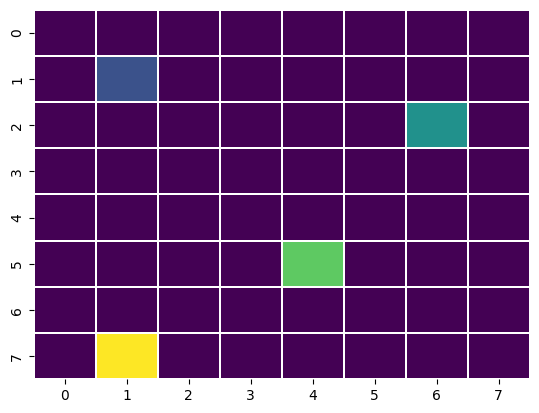

Zyski sieci zależą od budżetu wyłożonego na cztery pizzerie ($B_1$, $B_2$, $B_3$, $B_4$), gdzie każdy budżet jest w zakresie od **0 do 400** (nie może wyjść poza te wartości). Zysk jest liczony w następujący sposób:

$$
Z = \sum_{i=0}^8 \sum_{j=0}^8 \frac{z_{i,j}^1 + z_{i,j}^2 + z_{i,j}^3 + z_{i,j}^4}{4} - (B_1+B_2+B_3+B_4)^{1.15}
$$

Gdzie $z_{i,j}^k$ jest dochodem $k$-tej pizzerii na polu $(i,j)$. Innymi słowy, sumujemy **średnie zyski** z danego pola dla wszystkich pizzerii i odejmujemy od tego skorygowaną (potęgowaną) sumę budżetów — ze względu na konieczność rozbudowy lokali, większe trudności w utrzymaniu itp.

Zysk $k$-tej pizzerii na polu $(i,j)$ liczymy natomiast następująco:

Najpierw liczymy $d$, czyli odległość taksówkarską (taxicab, Manhattan Distance) między pizzerią a tym polem.

- Jeżeli $d$ jest **mniejsza** niż 2:

$$
z = 1.3 \cdot \frac{B}{0.5d + 4}
$$

- Jeżeli $d$ jest **większa lub równa** 2:

$$
z = \frac{B}{0.5d + 4}
$$

---

Proszę zaprojektować **algorytm genetyczny**, który otrzyma jak najwyższą wartość funkcji $Z(B_1, B_2, B_3, B_4)$ i przedstawić, jak radzi sobie przy 10 wywołaniach (jak wygląda średnia wyniku i odchylenie standardowe).

Proszę samodzielnie wybrać **kodowanie** (rzeczywistoliczbowe, całkowitoliczbowe, binarne), wybrać **algorytm mutacji i selekcji**, oraz przeprowadzić **testy parametrów**.
